<a href="https://colab.research.google.com/github/HeyWinTomsy/MN/blob/main/%D0%9B%D0%A03_%D0%90%D0%BD%D1%82%D1%80%D0%BE%D0%BF%D0%BE%D0%B2%D0%A4%D0%86%D0%A23_10_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
# Ваш код:
# Імпортуйте pandas, numpy, matplotlib.pyplot, seaborn та інші потрібні бібліотеки.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Завантаження даних
Оберіть **один** зі способів завантаження датасету.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [2]:
# Ваш код:
# Завантажте файл і збережіть дані у DataFrame `df`.
from google.colab import files

uploaded = files.upload()
csv_name = [name for name in uploaded if name.endswith('.csv')][0]
df = pd.read_csv(csv_name)
print(f'Завантажено файл: {csv_name}')
print(f'Розмір датасету: {df.shape}')
df.head()

Saving house_price_regression_dataset.csv to house_price_regression_dataset.csv
Завантажено файл: house_price_regression_dataset.csv
Розмір датасету: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [3]:
# Ваш код:
# Завантажте датасет з Kaggle та створіть DataFrame `df`.
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'home-value-insights' dataset.
Path to dataset files: /kaggle/input/home-value-insights


In [4]:
df = pd.read_csv(os.path.join(path,"house_price_regression_dataset.csv"))
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [5]:
# Ваш код:
# Виведіть кілька перших рядків та загальну інформацію про DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [6]:
# Ваш код:
# Порахуйте кількість дублікатів.
dublicates = df.duplicated().sum()
print(dublicates)

0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [7]:
# Ваш код:
# Виведіть кількість пропусків для кожної ознаки.
missed = df.isnull().sum()
print(missed)

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [8]:
# Ваш код:
# Отримайте описову статистику датасету.
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [9]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Neighborhood_Quality`.
df['Neighborhood_Quality'].value_counts()


,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

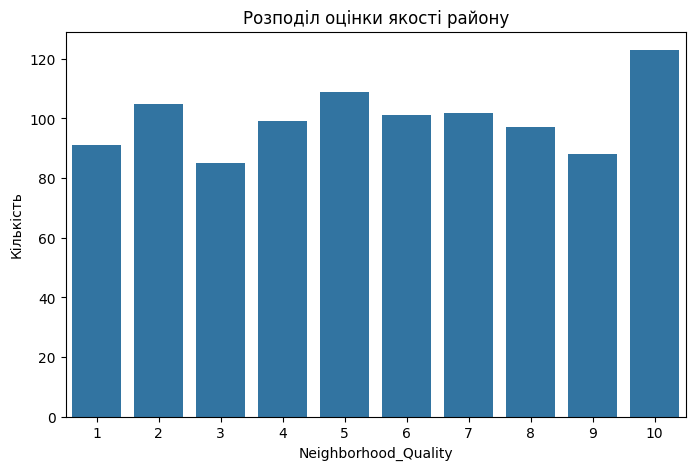

In [10]:
# Ваш код:
# Побудуйте countplot або іншу відповідну діаграму.

# Завдання 6: візуалізація
plt.figure(figsize=(8,5))
sns.countplot(x='Neighborhood_Quality', data=df)
plt.title('Розподіл оцінки якості району')
plt.xlabel('Neighborhood_Quality')
plt.ylabel('Кількість')
plt.show()




### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [11]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Num_Bathrooms`.
df['Num_Bathrooms'].value_counts()

,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

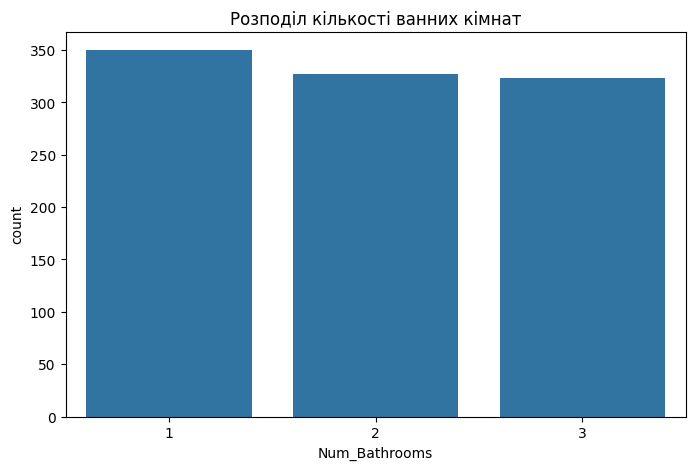

In [12]:
# Ваш код:
# Побудуйте відповідну діаграму.
plt.figure(figsize=(8,5))
sns.countplot(x='Num_Bathrooms', data=df)
plt.title('Розподіл кількості ванних кімнат')
plt.show()

### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

In [13]:
# Ваш код:
# Побудуйте pairplot або іншу попарну візуалізацію.





## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

<function matplotlib.pyplot.show(close=None, block=None)>

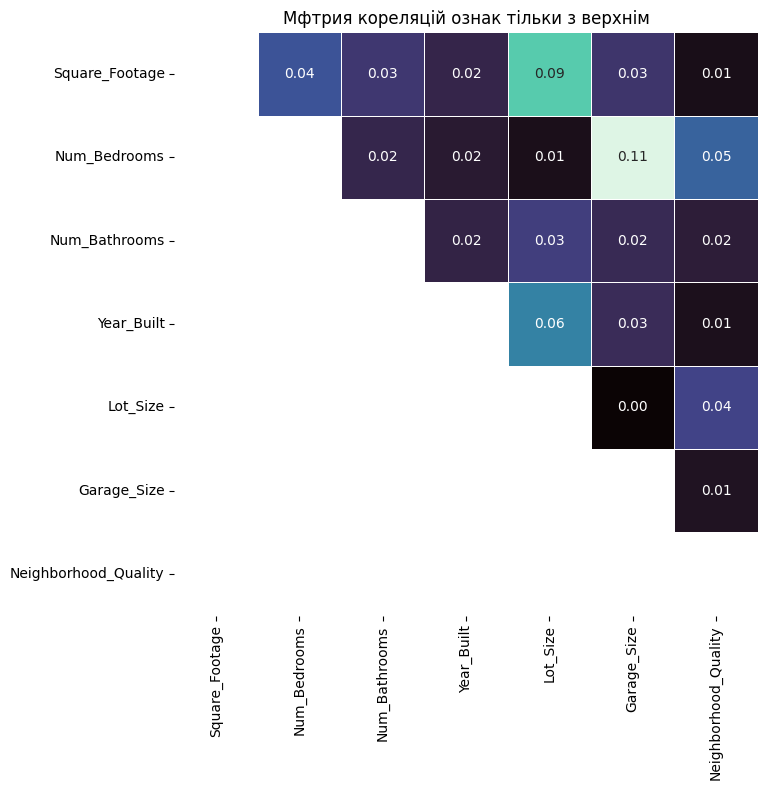

In [14]:
mtx = df.drop('House_Price',axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='mako',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Мфтрия кореляцій ознак тільки з верхнім", fontsize=12)
plt.tight_layout()
plt.show

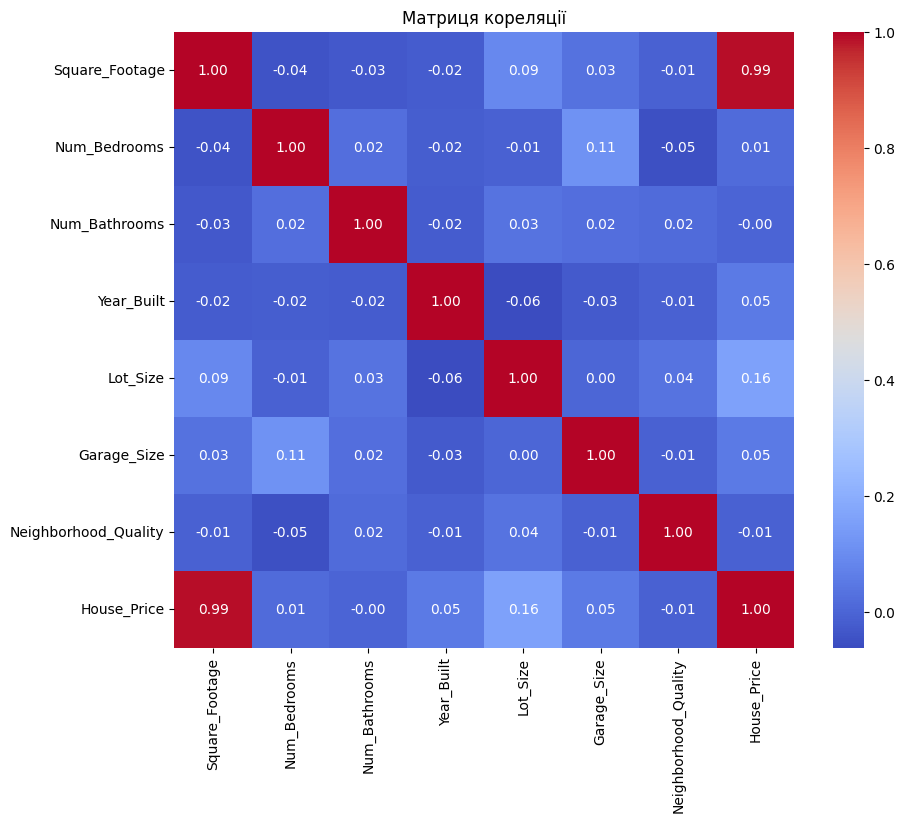

In [15]:
# Ваш код:
# Обчисліть кореляційну матрицю та побудуйте heatmap.
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матриця кореляції')
plt.show()

### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [16]:
# Ваш код:
# Виведіть кореляції ознак із `House_Price`.
df.corr()['House_Price'].sort_values(ascending=False)

,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [17]:
# Ваш код:
# Імпортуйте необхідні класи та функції зі scikit-learn.
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [18]:
# Ваш код:
# Створіть `X` та `y`.
X = df.drop('House_Price', axis=1)
y = df['House_Price']

### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [19]:
# Ваш код:
# Створіть `X_train`, `X_test`, `y_train`, `y_test`.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [20]:
# Ваш код:
# Створіть словник або іншу структуру з п’ятьма моделями.
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso())
    ]),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [21]:
# Ваш код:
# Навчіть усі моделі, отримайте прогнози та метрики на тестовій вибірці.
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results[name] = {'R2': r2, 'MAE': mae, 'MSE': mse}

results_df = pd.DataFrame(results).T
results_df

,R2,MAE,MSE
Linear Regression,0.998426,8174.583600,1.014348e+08
Ridge,0.998410,8241.586911,1.024810e+08
Lasso,0.998426,8174.748374,1.014366e+08
Random Forest,0.993886,16114.289644,3.941317e+08
Gradient Boosting,0.996510,12305.217615,2.249656e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

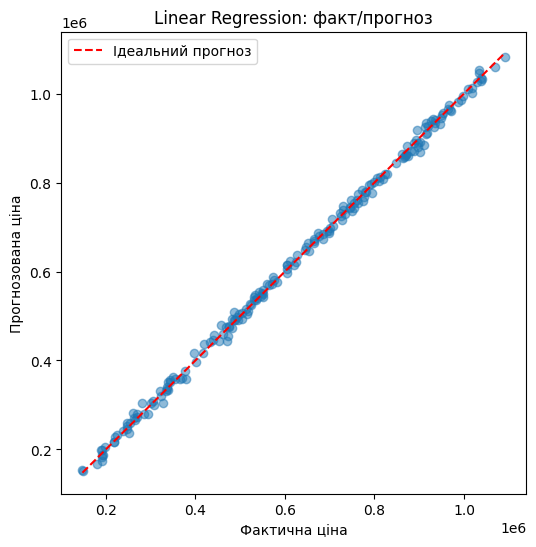

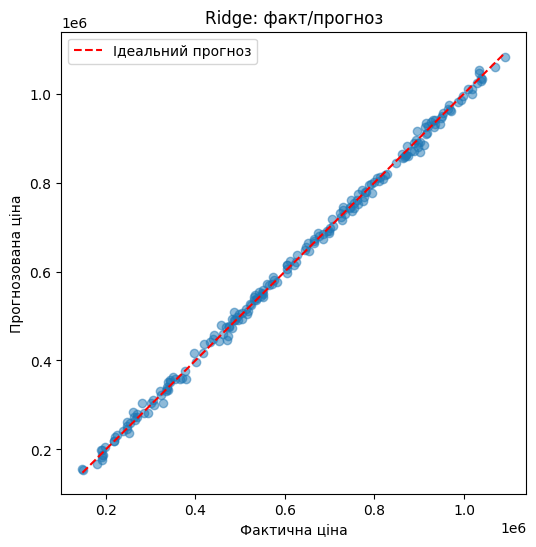

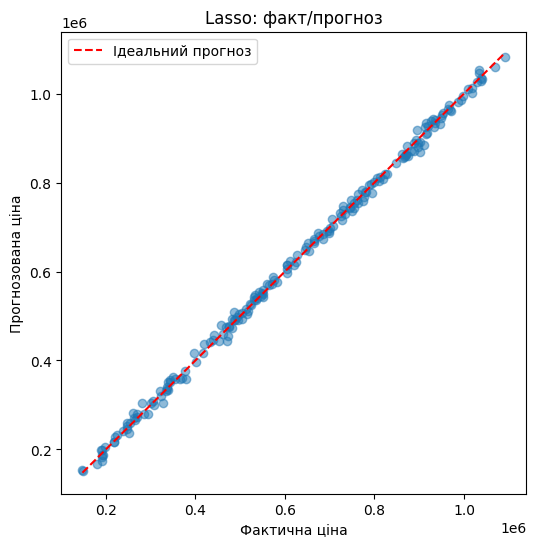

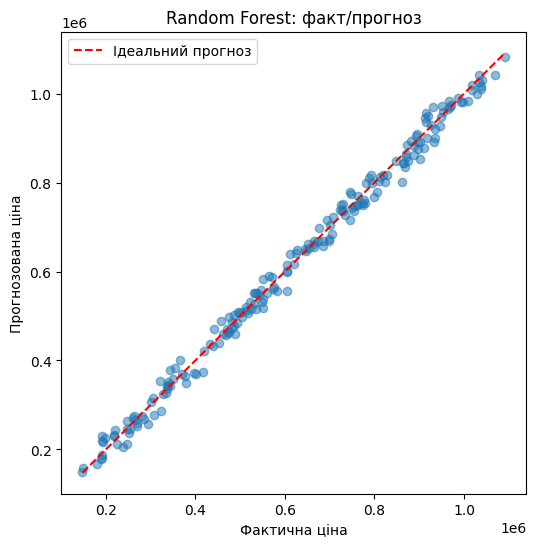

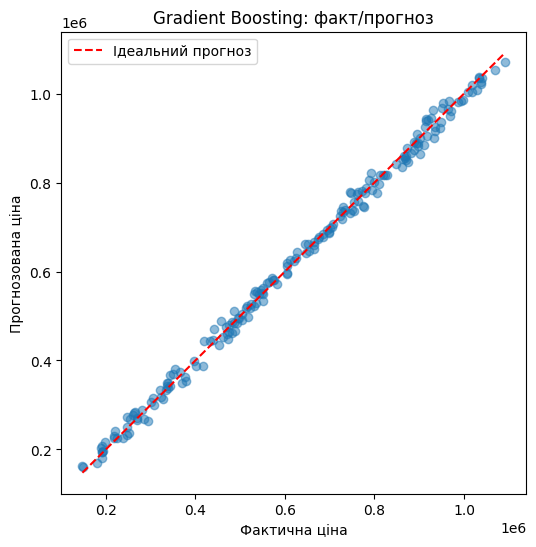

In [22]:
# Ваш код:
# Побудуйте окремий графік для кожної моделі.
for name, model in models.items():
    y_pred = model.predict(X_test)

    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', label='Ідеальний прогноз')
    plt.xlabel('Фактична ціна')
    plt.ylabel('Прогнозована ціна')
    plt.title(f'{name}: факт/прогноз')
    plt.legend()
    plt.show()

## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [23]:
# Ваш код:
# Створіть сітку параметрів, GridSearchCV і знайдіть найкращі параметри.
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Найкращі параметри:", grid_search.best_params_)

Найкращі параметри: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}


In [29]:
rf_optimal = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42
)

rf_optimal.fit(X_train,y_train)

y_pred_rf_optimal = rf_optimal.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf_optimal)
rf_mae = mean_absolute_error(y_test, y_pred_rf_optimal)
rf_r2 = r2_score(y_test, y_pred_rf_optimal)
rf_mape = mean_absolute_error(y_test, y_pred_rf_optimal)

### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [31]:
# Ваш код:
# Навчіть оптимізований Random Forest та обчисліть метрики.
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)

print(f"R²: {r2_best:.4f}, MAE: {mae_best:.2f}, MSE: {mse_best:.2f}")

R²: 0.9650, MAE: 35485.44, MSE: 2255499040.86


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [25]:
# Ваш код:
# Виведіть результати двох моделей у зручному для порівняння вигляді.
comparison = pd.DataFrame({
    'Base RF': results['Random Forest'],
    'Optimized RF': {'R2': r2_best, 'MAE': mae_best, 'MSE': mse_best}
})
comparison

,Base RF,Optimized RF
R2,9.938855e-01,9.650087e-01
MAE,1.611429e+04,3.548544e+04
MSE,3.941317e+08,2.255499e+09


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

Вона справді покращилась

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [26]:
# Ваш код:
# Сформуйте DataFrame з фактичними та прогнозованими значеннями і розрахуйте похибку у %.
lr_model = models['Linear Regression']
y_pred_lr = lr_model.predict(X_test)

comparison_table = pd.DataFrame({
    'Фактична ціна': y_test.values,
    'Прогнозована ціна': y_pred_lr,
    'Похибка (%)': abs(y_test.values - y_pred_lr) / y_test.values * 100
})

comparison_table.sample(10)

,Фактична ціна,Прогнозована ціна,Похибка (%)
167,1.908021e+05,1.820786e+05,4.571987
82,5.345330e+05,5.368163e+05,0.427154
45,1.008539e+06,1.011344e+06,0.278073
52,8.132968e+05,8.126157e+05,0.083745
49,6.949173e+05,6.922126e+05,0.389217
125,3.272535e+05,3.032741e+05,7.327454
60,9.932731e+05,9.858046e+05,0.751907
94,7.066863e+05,7.023933e+05,0.607484
103,6.051440e+05,6.151530e+05,1.653987
108,2.855465e+05,2.804582e+05,1.781965


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**